In [1]:

#import part
import src.make_map_list as mml
import src.dijkstra_route as dijk
import src.greedy_route as greedy
import src.Astar_route as astar

In [2]:
#make map list part
num_node = 100

result = mml.make_map(num_node)
print(result)

{'0': {'pos': (29, 19), 'edges': [('16', 7), ('86', 49)]}, '1': {'pos': (5, 5), 'edges': [('24', 70), ('20', 60)]}, '2': {'pos': (40, 23), 'edges': [('92', 55), ('33', 29)]}, '3': {'pos': (55, 46), 'edges': [('7', 31), ('21', 45)]}, '4': {'pos': (96, 92), 'edges': [('40', 65), ('10', 75)]}, '5': {'pos': (11, 99), 'edges': [('62', 48), ('32', 13)]}, '6': {'pos': (41, 93), 'edges': [('54', 65), ('73', 69)]}, '7': {'pos': (86, 46), 'edges': [('85', 70), ('24', 43)]}, '8': {'pos': (44, 68), 'edges': [('36', 24), ('35', 41)]}, '9': {'pos': (75, 38), 'edges': [('88', 67), ('43', 64)]}, '10': {'pos': (23, 71), 'edges': [('49', 44), ('9', 61)]}, '11': {'pos': (86, 8), 'edges': [('68', 58), ('66', 86)]}, '12': {'pos': (78, 57), 'edges': [('3', 25), ('98', 83)]}, '13': {'pos': (47, 87), 'edges': [('14', 41), ('25', 62)]}, '14': {'pos': (80, 62), 'edges': [('60', 62), ('87', 67)]}, '15': {'pos': (89, 16), 'edges': [('34', 86), ('67', 78)]}, '16': {'pos': (24, 14), 'edges': [('88', 79), ('13', 76)

In [3]:
print(result.keys())

dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99'])


In [4]:
dijk_ans = dijk.dijkstra(result,'0','90')
print(dijk_ans)

=== ダイクストラ法 計算結果 (始点: 0) ===
ノード 0  | 最小コスト:      0
-------------------------
ノード 1  | 最小コスト:    155
-------------------------
ノード 2  | 最小コスト:   到達不能
-------------------------
ノード 3  | 最小コスト:    294
-------------------------
ノード 4  | 最小コスト:    336
-------------------------
ノード 5  | 最小コスト:    221
-------------------------
ノード 6  | 最小コスト:    399
-------------------------
ノード 7  | 最小コスト:    325
-------------------------
ノード 8  | 最小コスト:    231
-------------------------
ノード 9  | 最小コスト:    244
-------------------------
ノード 10 | 最小コスト:    336
-------------------------
ノード 11 | 最小コスト:    372
-------------------------
ノード 12 | 最小コスト:    269
-------------------------
ノード 13 | 最小コスト:     83
-------------------------
ノード 14 | 最小コスト:    104
-------------------------
ノード 15 | 最小コスト:    435
-------------------------
ノード 16 | 最小コスト:      7
-------------------------
ノード 17 | 最小コスト:     66
-------------------------
ノード 18 | 最小コスト:   到達不能
-------------------------
ノード 19 | 最小コスト:    300
-----------------

In [5]:
greedy_ans = greedy.greedy_best_first(result,'0','90')
print(greedy_ans)

=== Greedy Best-First Search 結果 (始点: 0 -> 終点: 90) ===
[最短経路]: 0 -> 86 -> 70 -> 82 -> 97 -> 65 -> 27 -> 50 -> 90
[経路コスト]: 286
(['0', '86', '70', '82', '97', '65', '27', '50', '90'], 286)


In [6]:
astar_ans = astar.a_star(result,'0','90')
print(astar_ans)

=== A* アルゴリズム 結果 (始点: 0 -> 終点: 90) ===
[最短経路]: 0 -> 86 -> 70 -> 82 -> 97 -> 65 -> 27 -> 50 -> 90
[合計コスト]: 286
['0', '86', '70', '82', '97', '65', '27', '50', '90']


# 経路はAスターとダイクストラが同じ
    （つまりAスターで最短経路を出せている）

# 逆に貪欲法では結局コストが高くなってしまっている。

### 次はノード探索数を比べていく。全探索しないでできているはず。

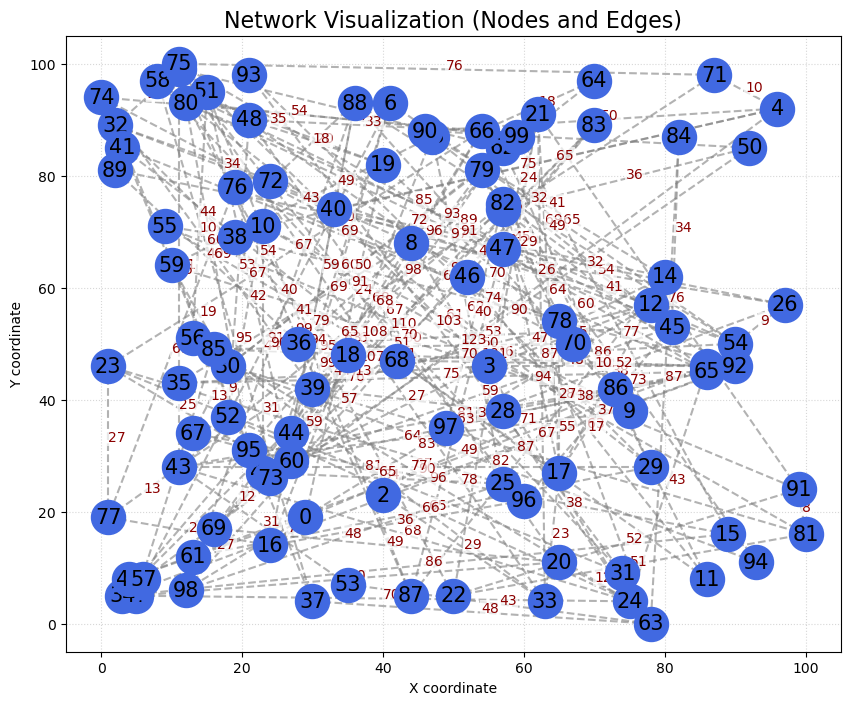

In [7]:
from src.Map_visualize import map_visualize

map_visualize(result)

In [8]:
from src.make_order import make_order

import csv
import os
import time
import numpy as np
import pandas as pd

ST_PENDING = "PENDING"
ST_ASSIGNED = "ASSIGNED"
ST_COMPLETED = "COMPLETED"

active_orders = {}

gen_prob = 0.3
deadtime = 100
current_time = 0
order_id_counter = 1

log_filename = "simulation_log_001.csv"

print("シミュレーションを開始します... (Ctrl+C で停止)")

try:
    while True:
        # 1. 新しいオーダーの発生（辞書への追加：超高速かつ省メモリ）
        if np.random.rand() < gen_prob:
            oid = f"ORD_{order_id_counter:05d}"
            new_ord = make_order(
                num_node, current_time, deadtime, oid
            )
            active_orders[oid] = new_ord  # 辞書に直接追加
            order_id_counter += 1

        # 2. 状態の変化（ダミーロジック）
        # 辞書型なので、特定のオーダーのステータス書き換えがピンポイントで一瞬で終わる
        for oid, order in active_orders.items():
            if order["status"] == ST_PENDING and np.random.rand() < 0.1:
                order["status"] = ST_ASSIGNED

            # 10ステップ経ったら完了にする
            if (current_time - order["generation_time"]) > 10:
                order["status"] = ST_COMPLETED

        # 3. 【メモリ解放の肝】完了したオーダーを抽出し、辞書から『完全に削除』
        # ループ中に辞書のサイズを変えるとエラーになるため、まず削除対象のIDをリストアップ
        completed_ids = [
            oid
            for oid, order in active_orders.items()
            if order["status"] == ST_COMPLETED
        ]

        if completed_ids:
            completed_list = []
            for oid in completed_ids:
                # .pop() は辞書からそのデータを『取り出して消す』。
                # これによりPythonのメモリから完全に参照が消える
                order_data = active_orders.pop(oid)
                completed_list.append(order_data)

            # 完了した分だけCSVに追記保存
            df_to_save = pd.DataFrame(completed_list)
            df_to_save.to_csv(

                log_filename,
                mode="a",
                header=not os.path.exists(log_filename),
                index=False,
            )

        # 4. もし現在の状態を分析したり、画面表示でDataFrameとして扱いたい場合
        # その瞬間の辞書の「値（values）」だけを渡せば、一瞬でDataFrame化できます。
        if current_time % 10 == 0:  # 10ステップに1回だけ表示
            if active_orders:
                # 辞書からその時だけDFを作る（元の辞書は汚さない）
                df_current = pd.DataFrame(active_orders.values())
                print(
                    f"\n--- Time: {current_time} (アクティブオーダー一覧) ---"
                )
                print(df_current[["order_id", "status"]].tail())
            else:
                print(f"\nTime: {current_time} | 稼働中のオーダーなし")

        current_time += 1
        time.sleep(0.1)

except KeyboardInterrupt:
    print("\nシミュレーションを終了しました。")
    

シミュレーションを開始します... (Ctrl+C で停止)

Time: 0 | 稼働中のオーダーなし

--- Time: 10 (アクティブオーダー一覧) ---
    order_id    status
0  ORD_00001  ASSIGNED
1  ORD_00002  ASSIGNED

--- Time: 20 (アクティブオーダー一覧) ---
    order_id    status
0  ORD_00003  ASSIGNED
1  ORD_00004   PENDING

--- Time: 30 (アクティブオーダー一覧) ---
    order_id    status
0  ORD_00005  ASSIGNED
1  ORD_00006   PENDING
2  ORD_00007  ASSIGNED

--- Time: 40 (アクティブオーダー一覧) ---
    order_id    status
0  ORD_00007  ASSIGNED
1  ORD_00008   PENDING
2  ORD_00009   PENDING
3  ORD_00010  ASSIGNED
4  ORD_00011  ASSIGNED

--- Time: 50 (アクティブオーダー一覧) ---
    order_id    status
0  ORD_00012  ASSIGNED
1  ORD_00013  ASSIGNED
2  ORD_00014   PENDING

--- Time: 60 (アクティブオーダー一覧) ---
    order_id    status
0  ORD_00015  ASSIGNED
1  ORD_00016   PENDING
2  ORD_00017  ASSIGNED
3  ORD_00018   PENDING

--- Time: 70 (アクティブオーダー一覧) ---
    order_id    status
0  ORD_00018  ASSIGNED
1  ORD_00019   PENDING
2  ORD_00020  ASSIGNED
3  ORD_00021   PENDING
4  ORD_00022  ASSIGNED

Time: 80 

    order_id    status
0  ORD_00218   PENDING
1  ORD_00219  ASSIGNED
2  ORD_00220   PENDING
3  ORD_00221  ASSIGNED


In [ ]:
from src.Agent import Agent
import random

num_node2 = 30
num_agent = 3
attitude = astar
agents = {}

result2 = mml.make_map(num_node2)
node_list = list(result2.keys())


for i in range(num_agent):
    start_node = random.choice(node_list)
    agent_id = f"AMR_{i}"

    agents[i] = Agent(
        agent_id = agent_id,
        start_node= start_node,
        vehicle_speed=30,
        attitude=attitude
    )

#初期配置の確認プリント
print("--- エージェント初期化完了 ---")
for idx, ag in agents.items():
    print(f"Index: {idx} | ID: {ag.agent_id} | 現在地ノード: {ag.current_node} | 速度: {ag.speed}")

--- エージェント初期化完了 ---
Index: 0 | ID: AMR_0 | 現在地ノード: 24 | 速度: 30
Index: 1 | ID: AMR_1 | 現在地ノード: 24 | 速度: 30
Index: 2 | ID: AMR_2 | 現在地ノード: 6 | 速度: 30
